# Resampling and Simulation

### Bootstrap

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("paddydataset.csv")

# clean column names and rename yield column
df.columns = df.columns.str.strip()
df = df.rename(columns={"Paddy yield(in Kg)": "yield"})

# filter data into two varieties and calculate observed difference
delux_ponni = df[df["Variety"] == "delux ponni"]["yield"]
ponmani = df[df["Variety"] == "ponmani"]["yield"]

obs_diff = delux_ponni.mean() - ponmani.mean()

# set parameters for bootstrapping loop
rng = np.random.default_rng(3026)

B = 10000
boot_diffs = []

# perform bootstrapping by resampling with replacement and calculating mean differences
for _ in range(B):
    s1 = rng.choice(delux_ponni, size=len(delux_ponni), replace=True)
    s2 = rng.choice(ponmani, size=len(ponmani), replace=True)
    boot_diffs.append(s1.mean() - s2.mean())

boot_diffs = np.array(boot_diffs)

# calculate 95% confidence interval from bootstrapped differences
ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)

print("Observed difference in yield:", obs_diff)
print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

Observed difference in yield: 203.33952586973828
95% CI: (-596.6667, 1006.3616)


### Monte Carlo

In [2]:
# set parameters for monte carlo simulation
rng = np.random.default_rng(3026)

B = 10000
sim_diffs = []

mu = df["yield"].mean()
sigma = df["yield"].std()

n1 = len(delux_ponni)
n2 = len(ponmani)

# perform monte carlo simulation by generating random samples from normal distribution and calculating mean differences
for _ in range(B):
    sim1 = rng.normal(mu, sigma, n1)
    sim2 = rng.normal(mu, sigma, n2)
    
    sim_diffs.append(sim1.mean() - sim2.mean())

sim_diffs = np.array(sim_diffs)

# calculate mean, std, and 95% range of simulated differences
print("Mean simulated difference in yield:", sim_diffs.mean())
print("Std of simulated differences in yield:", sim_diffs.std())

print(f"95% range: ({np.percentile(sim_diffs, 2.5):.4f}, {np.percentile(sim_diffs, 97.5):.4f})")

Mean simulated difference in yield: 0.046104470328416934
Std of simulated differences in yield: 409.05305420477384
95% range: (-804.8539, 792.0781)


### Plot

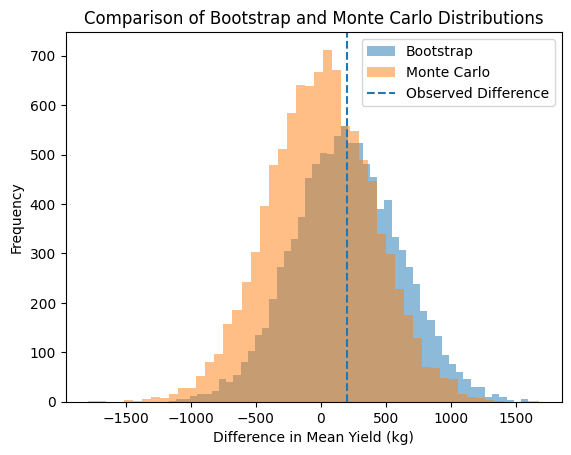

In [3]:
import matplotlib.pyplot as plt

plt.figure()

# bootstrap distribution
plt.hist(boot_diffs, bins=50, alpha=0.5, label="Bootstrap")

# simulation distribution
plt.hist(sim_diffs, bins=50, alpha=0.5, label="Monte Carlo")

# observed difference
plt.axvline(obs_diff, linestyle='dashed', label="Observed Difference")

plt.title("Comparison of Bootstrap and Monte Carlo Distributions")
plt.xlabel("Difference in Mean Yield (kg)")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("paddy.png")

plt.show()